# V1 — Temporal Feature Distribution & Drift Analysis

Diagnostic notebook to investigate **why V1 calibration changes across mortgage vintages**.

The previous calibration experiment showed:
- calibration slope around 1.1–1.2 for 2015–2017;
- slope falling to about 0.73 in 2018 and 0.60 in 2019;
- global sigmoid/isotonic calibration trained on 2015–2017 did not generalize consistently to OOT;
- materially different observed event rates in later vintages.

**Question:** Is the deterioration caused by the borrower/loan population changing over time, by the feature-to-target relationship changing, or by both?

This notebook is diagnostic only. It does not retrain V1, recalibrate probabilities, or modify the production pipeline.


## Diagnostic framework

### Population / covariate shift

Feature distributions change over time:

```text
2015 → 2019
  ↓
credit score distribution
LTV distribution
DTI distribution
loan characteristics
geography
missingness
etc.
```

### Relationship / concept drift

Feature distributions may remain similar, but:

```text
P(target | features)
```

changes over time.

We first measure feature distribution shift, then inspect feature-level event-rate behaviour by vintage.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from credit_risk.utils.config import create_path
import os 
PROJECT_ROOT = Path.cwd().parent.resolve()
os.chdir(PROJECT_ROOT)
with (PROJECT_ROOT / "config" / "parameters" / "base.yml").open(
    "r", encoding="utf-8"
) as file:
    parameters = yaml.safe_load(file)

with (PROJECT_ROOT / "config" / "catalog" / "base.yml").open(
    "r", encoding="utf-8"
) as file:
    catalog = yaml.safe_load(file)

config = {**parameters, **catalog}

data_config = config["parameters"]["data"]
modelling_config = config["parameters"]["modelling"]

approach = config["parameters"]["modelling_approach"]
provider = data_config["data_provider"]

validation_vintages = [int(v) for v in config['parameters']['modelling']["vintages_train"]]
oot_vintages = [int(v) for v in config['parameters']['modelling']["vintages_oot"]]
all_vintages = validation_vintages + oot_vintages

target_column = "ever_90dpd_24m"

print("Validation vintages:", validation_vintages)
print("OOT vintages:", oot_vintages)


Validation vintages: [2015, 2016, 2017]
OOT vintages: [2018, 2019]


## Load persisted V1 model-input populations

These are the same loan-level model-input datasets used by V1 modelling/evaluation.


In [2]:
population_frames = []

for vintage in all_vintages:
    path = create_path(
        config["catalog"]["base"],
        config["catalog"],
        "model_input_path",
        approach,
        provider,
        vintage,
        must_exist=True,
    )

    df = pd.read_parquet(path).copy()
    df["vintage"] = vintage
    population_frames.append(df)

population = pd.concat(population_frames, ignore_index=True)

print("Rows:", f"{len(population):,}")
print("Columns:", population.shape[1])
print("Vintages:", sorted(population["vintage"].unique()))

display(
    population.groupby("vintage")[target_column]
    .agg(population="size", events="sum", event_rate="mean")
)


Rows: 239,492
Columns: 27
Vintages: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]


,population,events,event_rate
vintage,,,
2015,47255,343,0.007258
2016,48046,401,0.008346
2017,48242,509,0.010551
2018,47394,1287,0.027155
2019,48555,2256,0.046463


## Resolve the V1 feature contract

Use the saved training feature contract where available; otherwise use the configured V1 feature list.


In [3]:
# artifact_root = create_path(
#     config["catalog"]["base"],
#     config["catalog"],
#     "model_artifact_path",
#     approach,
#     modelling_config["version"],
#     modelling_config["algorithm"],
#     must_exist=True,
# )

artifact_root = Path("data/05_artifacts/origination/test_unbalanced/xgboost")
metadata_candidates = [
    artifact_root / "training_metadata.json",
    artifact_root / "metadata.json",
    artifact_root / "training_metadata.yml",
    artifact_root / "training_metadata.yaml",
]

metadata_path = next((p for p in metadata_candidates if p.exists()), None)
metadata = None

if metadata_path is not None:
    if metadata_path.suffix == ".json":
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    else:
        metadata = yaml.safe_load(metadata_path.read_text(encoding="utf-8"))

features = None

if isinstance(metadata, dict):
    for key_path in [
        ("features",),
        ("training", "features"),
        ("modeling", "features"),
        ("modelling", "features"),
    ]:
        value = metadata
        for key in key_path:
            if not isinstance(value, dict) or key not in value:
                value = None
                break
            value = value[key]
        if isinstance(value, list):
            features = value
            break

if features is None:
    features = modelling_config["features"]

features = list(features.values())
features = [item for sublist in features for item in sublist]
missing_features = [f for f in features if f not in population.columns]
if missing_features:
    raise KeyError(f"V1 features missing from model-input data: {missing_features}")

numeric_features = [
    f for f in features if pd.api.types.is_numeric_dtype(population[f])
]
categorical_features = [f for f in features if f not in numeric_features]

print("Feature count:", len(features))
print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))

Feature count: 20
Numeric: 8
Categorical: 12


## Missingness by vintage

Missingness itself can be a source of population shift.


In [4]:
missingness_rows = []

for vintage, group in population.groupby("vintage", sort=True):
    for feature in features:
        missingness_rows.append({
            "vintage": int(vintage),
            "feature": feature,
            "missing_rate": group[feature].isna().mean(),
        })

missingness_by_vintage = pd.DataFrame(missingness_rows)

missingness_pivot = missingness_by_vintage.pivot(
    index="feature",
    columns="vintage",
    values="missing_rate",
)

display(missingness_pivot)


vintage,2015,2016,2017,2018,2019
feature,,,,,
channel,0.000000,0.000000,0.000000,0.000000,0.000000
credit_score_bins,0.000000,0.000000,0.000166,0.000169,0.000288
first_time_homebuyer_flag,0.000021,0.000000,0.000000,0.000000,0.000000
harp_indicator,0.000000,0.000000,0.000000,0.000000,0.000000
loan_purpose,0.000000,0.000000,0.000000,0.000000,0.000000
mi_percentage,0.000000,0.000000,0.000000,0.000000,0.000000
msa,0.114972,0.102527,0.109842,0.105351,0.092637
number_of_borrowers,0.000000,0.000000,0.000000,0.000000,0.000000
occupancy_status,0.000000,0.000000,0.000000,0.000000,0.000000


## Missingness change: earliest vs latest vintage


In [5]:
missingness_change = (
    missingness_pivot[all_vintages[-1]]
    - missingness_pivot[all_vintages[0]]
).sort_values(key=lambda s: s.abs(), ascending=False)

display(
    missingness_change.to_frame(
        name=f"missing_rate_change_{all_vintages[-1]}_vs_{all_vintages[0]}"
    )
)


,missing_rate_change_2019_vs_2015
feature,
original_dti,-0.081871
msa,-0.022335
credit_score_bins,0.000288
first_time_homebuyer_flag,-0.000021
original_cltv_bins,-0.000021
original_ltv_bins,-0.000021
harp_indicator,0.000000
channel,0.000000
number_of_borrowers,0.000000


## Numeric distribution shift — PSI

PSI is used here as a **screening diagnostic**, not as a production decision rule.

The earliest development vintage is the reference population. Quantile bins are created from that reference.


In [6]:
def quantile_bins(reference, n_bins=10):
    reference = pd.Series(reference).dropna()
    quantiles = np.linspace(0, 1, n_bins + 1)
    bins = np.sort(reference.quantile(quantiles).unique())

    if len(bins) < 3:
        return None

    bins[0] = -np.inf
    bins[-1] = np.inf
    return bins


def psi_from_bins(reference, current, bins, epsilon=1e-6):
    reference = pd.Series(reference).dropna()
    current = pd.Series(current).dropna()

    reference_counts = pd.cut(
        reference, bins=bins, include_lowest=True
    ).value_counts(sort=False)

    current_counts = pd.cut(
        current, bins=bins, include_lowest=True
    ).value_counts(sort=False)

    reference_pct = (
        reference_counts / reference_counts.sum()
    ).clip(lower=epsilon)

    current_pct = (
        current_counts / current_counts.sum()
    ).clip(lower=epsilon)

    return float(
        (
            (current_pct - reference_pct)
            * np.log(current_pct / reference_pct)
        ).sum()
    )


reference_vintage = all_vintages[0]
latest_vintage = all_vintages[-1]

reference = population[population["vintage"] == reference_vintage]

psi_rows = []

for feature in numeric_features:
    bins = quantile_bins(reference[feature])
    if bins is None:
        continue

    for vintage in all_vintages:
        current = population[population["vintage"] == vintage]

        psi_rows.append({
            "feature": feature,
            "vintage": vintage,
            "reference_vintage": reference_vintage,
            "psi": psi_from_bins(
                reference[feature],
                current[feature],
                bins,
            ),
        })

numeric_psi = pd.DataFrame(psi_rows)

numeric_psi_pivot = numeric_psi.pivot(
    index="feature",
    columns="vintage",
    values="psi",
)

display(numeric_psi_pivot)


vintage,2015,2016,2017,2018,2019
feature,,,,,
mi_percentage,0.0,0.000680,0.011760,0.034905,0.027078
original_dti,0.0,0.001153,0.021612,0.068470,0.033438
original_interest_rate,0.0,0.253068,0.234081,2.363145,0.393839
original_loan_term,0.0,0.000869,0.012725,0.055158,0.050199
original_upb,0.0,0.013320,0.005270,0.007239,0.065919
original_upb_log,0.0,0.013320,0.005270,0.007239,0.065919


## Rank numeric features by latest-vintage distribution shift


In [7]:
numeric_psi_ranked = (
    numeric_psi[numeric_psi["vintage"] == latest_vintage]
    .sort_values("psi", ascending=False)
)

display(numeric_psi_ranked)


,feature,vintage,reference_vintage,psi
19,original_interest_rate,2019,2015,0.393839
14,original_upb,2019,2015,0.065919
29,original_upb_log,2019,2015,0.065919
24,original_loan_term,2019,2015,0.050199
4,original_dti,2019,2015,0.033438
9,mi_percentage,2019,2015,0.027078


## Categorical distribution shift

For each categorical feature, compare category proportions against the earliest vintage.

The reported value is the largest absolute category-share change.


In [8]:
categorical_shift_rows = []

reference = population[population["vintage"] == reference_vintage]

for feature in categorical_features:
    reference_dist = (
        reference[feature]
        .fillna("__MISSING__")
        .value_counts(normalize=True)
    )

    for vintage in all_vintages[1:]:
        current = population[population["vintage"] == vintage]

        current_dist = (
            current[feature]
            .fillna("__MISSING__")
            .value_counts(normalize=True)
        )

        categories = reference_dist.index.union(current_dist.index)

        comparison = pd.DataFrame({
            "reference": reference_dist.reindex(
                categories, fill_value=0
            ),
            "current": current_dist.reindex(
                categories, fill_value=0
            ),
        })

        comparison["absolute_share_change"] = (
            comparison["current"] - comparison["reference"]
        ).abs()

        categorical_shift_rows.append({
            "feature": feature,
            "vintage": vintage,
            "max_absolute_category_shift": (
                comparison["absolute_share_change"].max()
            ),
            "category_with_max_shift": (
                comparison["absolute_share_change"].idxmax()
            ),
        })

categorical_shift = pd.DataFrame(categorical_shift_rows)

display(categorical_shift)


TypeError: Cannot setitem on a Categorical with a new category (__MISSING__), set the categories first

## Rank categorical features by latest-vintage shift


In [ ]:
categorical_shift_ranked = (
    categorical_shift[categorical_shift["vintage"] == latest_vintage]
    .sort_values(
        "max_absolute_category_shift",
        ascending=False,
    )
)

display(categorical_shift_ranked)


## Plot the strongest numeric distribution shifts


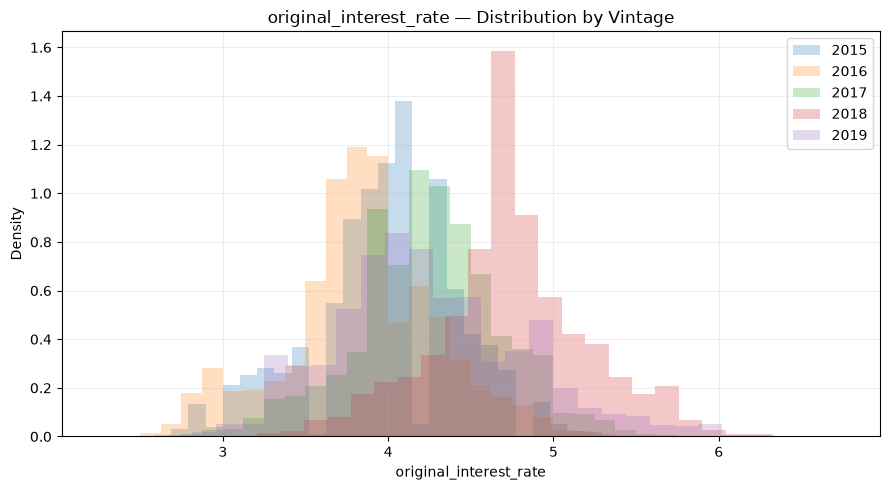

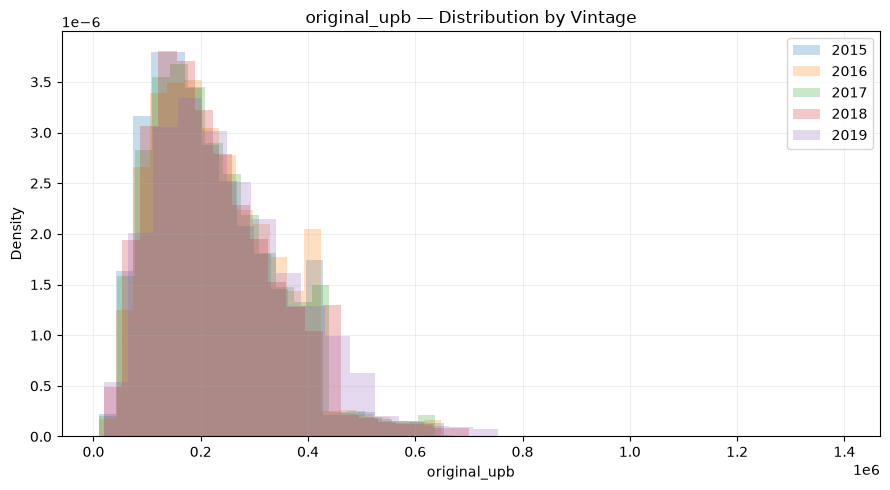

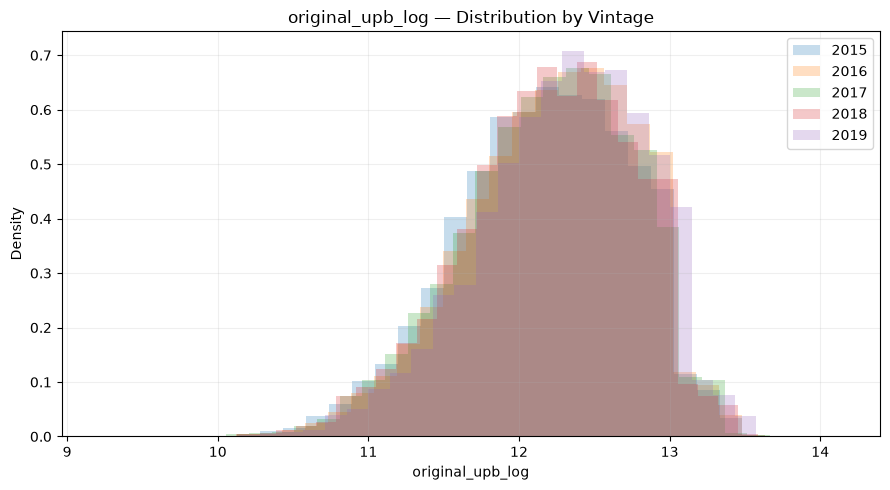

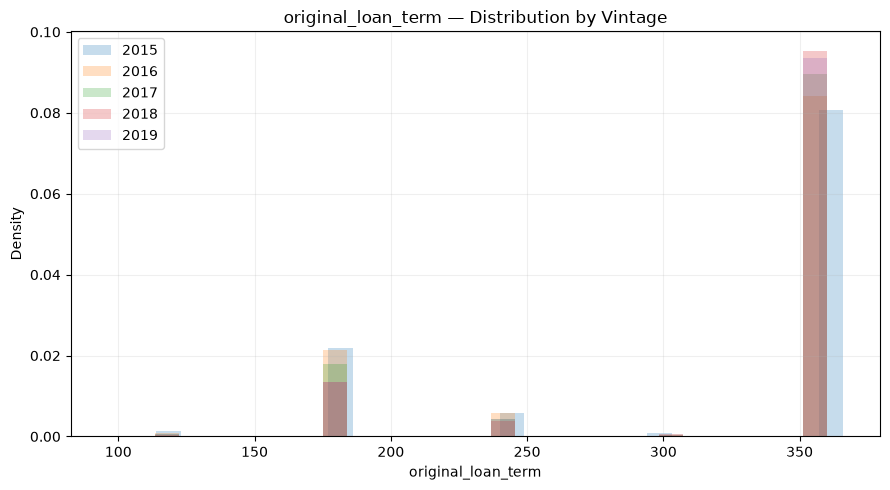

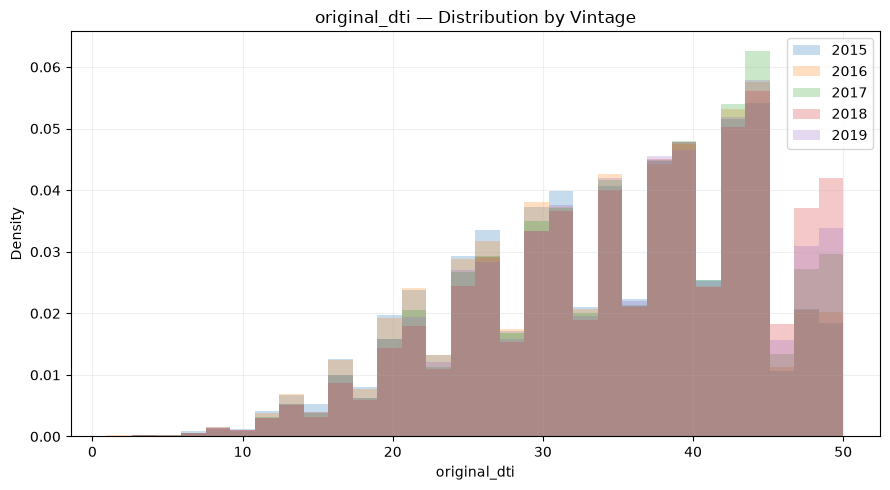

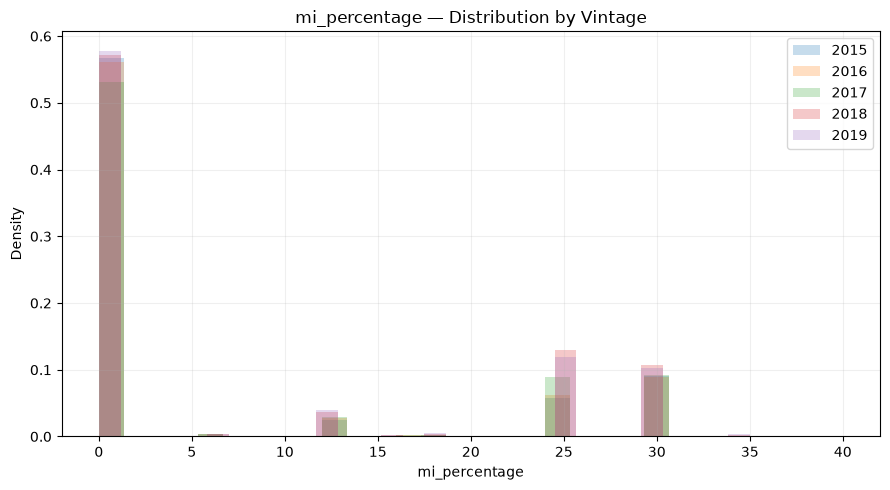

In [9]:
top_numeric_features = (
    numeric_psi_ranked.head(min(6, len(numeric_psi_ranked)))
    ["feature"]
    .tolist()
)

for feature in top_numeric_features:
    fig, ax = plt.subplots(figsize=(9, 5))

    for vintage in all_vintages:
        series = population.loc[
            population["vintage"] == vintage,
            feature,
        ].dropna()

        if series.empty:
            continue

        ax.hist(
            series,
            bins=30,
            density=True,
            alpha=0.25,
            label=str(vintage),
        )

    ax.set_title(f"{feature} — Distribution by Vintage")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(alpha=0.2)

    fig.tight_layout()
    plt.show()


## Numeric feature → target relationship by vintage

Distribution shift does not prove concept drift.

To investigate relationship drift, numeric features are binned using **reference-vintage quantiles**, then event rates are calculated separately by vintage.


In [10]:
numeric_event_rate_rows = []

for feature in numeric_features:
    bins = quantile_bins(reference[feature])
    if bins is None:
        continue

    temp = population[
        ["vintage", target_column, feature]
    ].copy()

    temp["feature_bin"] = pd.cut(
        temp[feature],
        bins=bins,
        include_lowest=True,
    )

    grouped = (
        temp.dropna(subset=["feature_bin"])
        .groupby(
            ["vintage", "feature_bin"],
            observed=False,
        )[target_column]
        .agg(
            population="size",
            events="sum",
            event_rate="mean",
        )
        .reset_index()
    )

    grouped["feature"] = feature
    numeric_event_rate_rows.append(grouped)

numeric_event_rates = pd.concat(
    numeric_event_rate_rows,
    ignore_index=True,
)

display(numeric_event_rates.head())


,vintage,feature_bin,population,events,event_rate,feature
0,2015,"(-inf, 21.0]",5095,9,0.001766,original_dti
1,2015,"(21.0, 25.0]",3899,13,0.003334,original_dti
2,2015,"(25.0, 29.0]",4838,16,0.003307,original_dti
3,2015,"(29.0, 32.0]",4202,22,0.005236,original_dti
4,2015,"(32.0, 35.0]",4364,36,0.008249,original_dti


## Rank numeric relationship shifts

For each feature, compare binned event rates between the earliest development vintage and the latest OOT vintage.


In [11]:
numeric_event_shift_rows = []

for feature, group in numeric_event_rates.groupby(
    "feature",
    sort=False,
):
    pivot = group.pivot(
        index="feature_bin",
        columns="vintage",
        values="event_rate",
    )

    if (
        reference_vintage not in pivot.columns
        or latest_vintage not in pivot.columns
    ):
        continue

    difference = (
        pivot[latest_vintage]
        - pivot[reference_vintage]
    ).abs()

    numeric_event_shift_rows.append({
        "feature": feature,
        "max_absolute_event_rate_change": difference.max(),
        "mean_absolute_event_rate_change": difference.mean(),
    })

numeric_event_shift = (
    pd.DataFrame(numeric_event_shift_rows)
    .sort_values(
        "max_absolute_event_rate_change",
        ascending=False,
    )
)

display(numeric_event_shift)


,feature,max_absolute_event_rate_change,mean_absolute_event_rate_change
0,original_dti,0.069100,0.038532
1,mi_percentage,0.056521,0.047420
2,original_upb,0.052487,0.038020
5,original_upb_log,0.052487,0.038020
4,original_loan_term,0.041564,0.030896
3,original_interest_rate,0.041017,0.034360


## Plot the strongest numeric relationship shifts


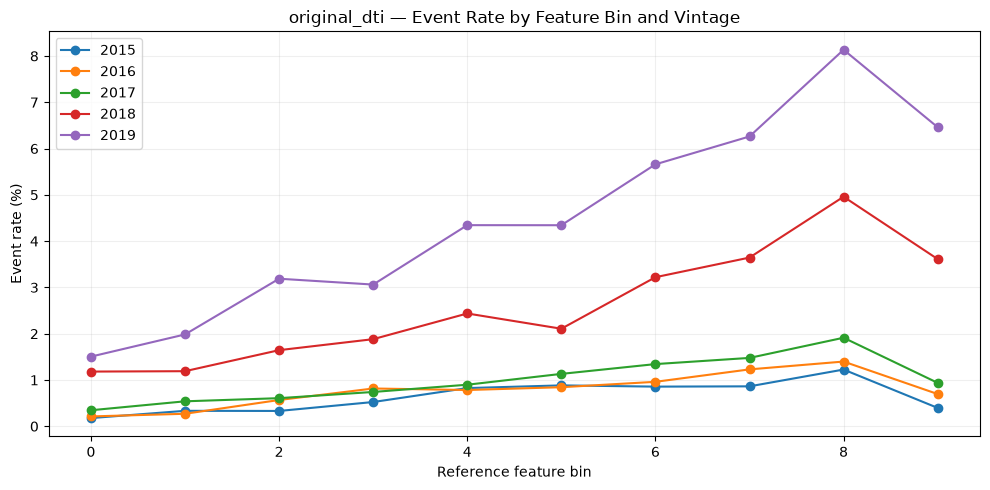

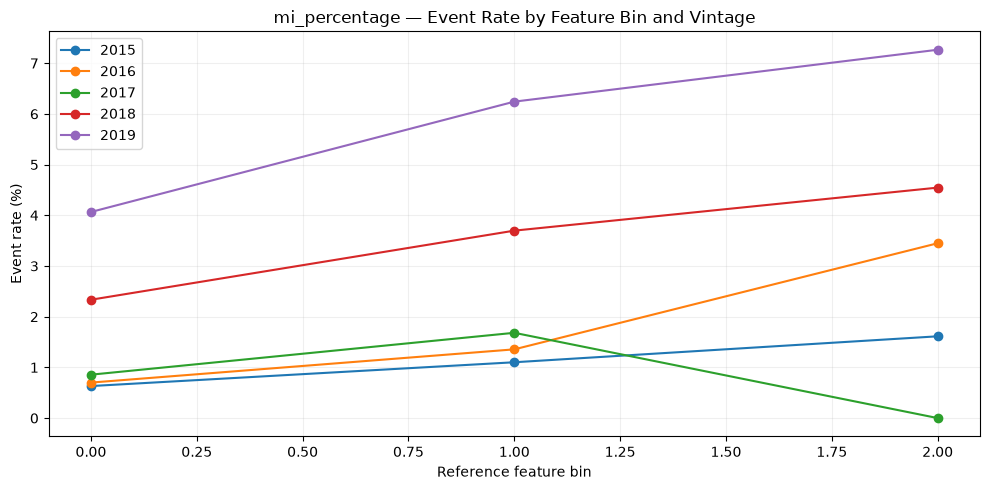

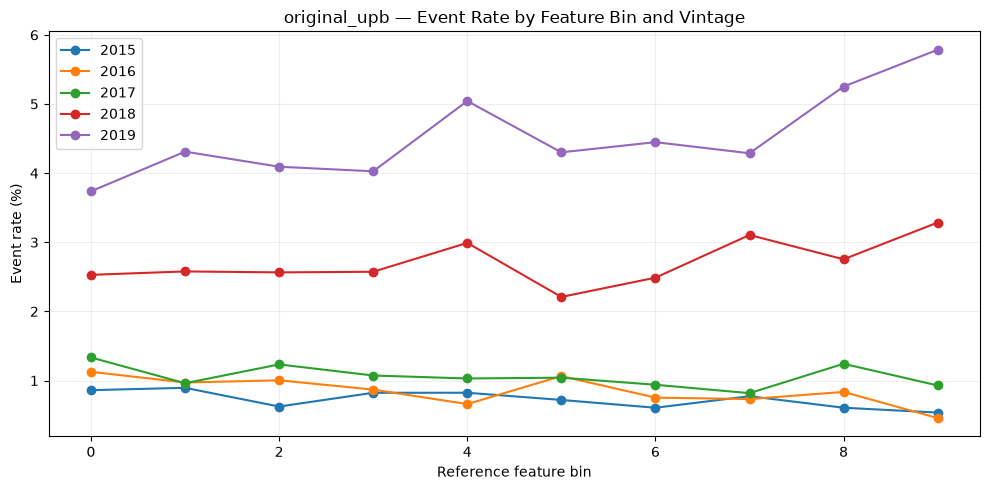

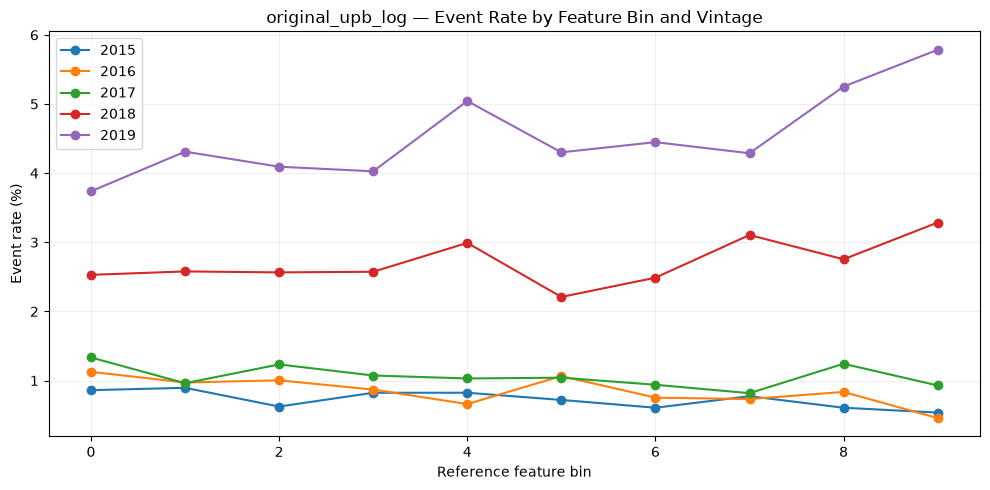

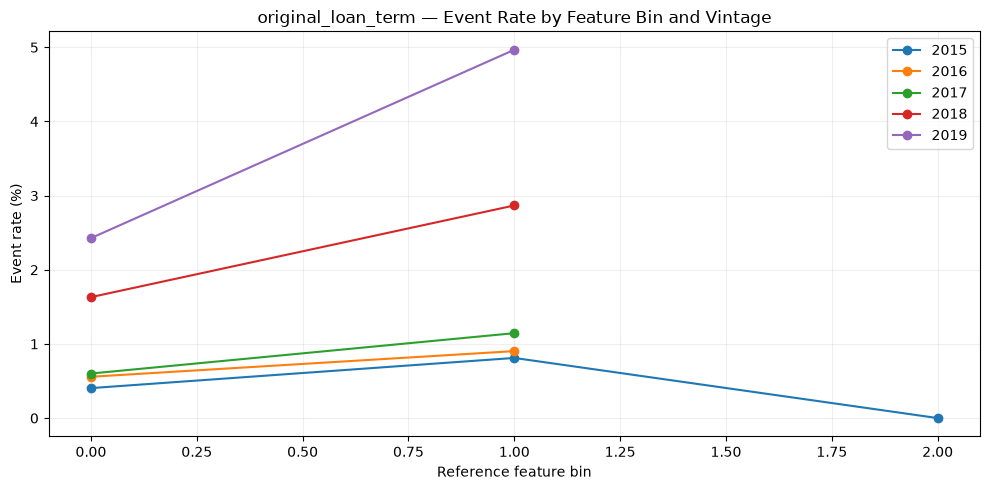

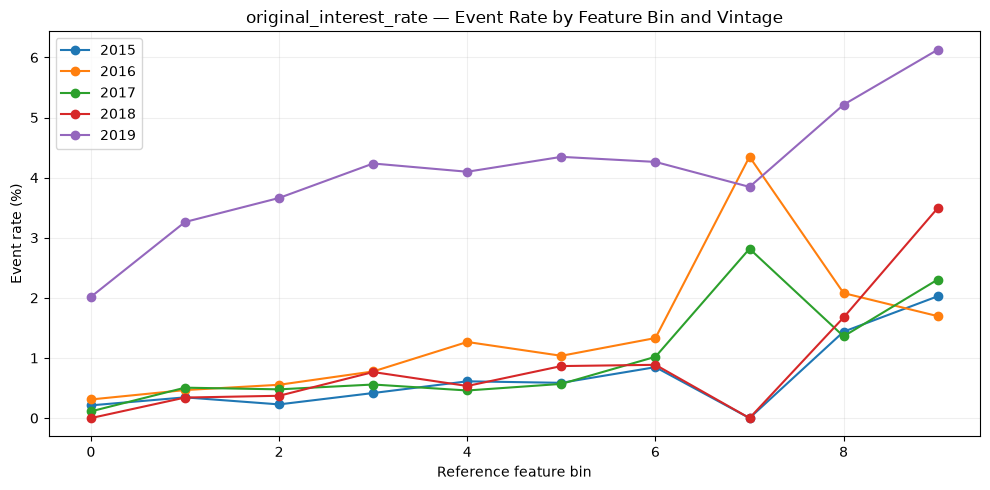

In [12]:
top_relationship_features = (
    numeric_event_shift
    .head(min(6, len(numeric_event_shift)))
    ["feature"]
    .tolist()
)

for feature in top_relationship_features:
    subset = numeric_event_rates[
        numeric_event_rates["feature"] == feature
    ]

    pivot = subset.pivot(
        index="feature_bin",
        columns="vintage",
        values="event_rate",
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    for vintage in all_vintages:
        if vintage not in pivot.columns:
            continue

        ax.plot(
            range(len(pivot)),
            pivot[vintage] * 100,
            marker="o",
            label=str(vintage),
        )

    ax.set_title(
        f"{feature} — Event Rate by Feature Bin and Vintage"
    )
    ax.set_xlabel("Reference feature bin")
    ax.set_ylabel("Event rate (%)")
    ax.legend()
    ax.grid(alpha=0.2)

    fig.tight_layout()
    plt.show()


## Categorical feature → target relationship by vintage


In [13]:
categorical_event_rows = []

for feature in categorical_features:
    temp = population[
        ["vintage", target_column, feature]
    ].copy()

    temp[feature] = temp[feature].fillna("__MISSING__")

    grouped = (
        temp.groupby(
            ["vintage", feature],
            observed=False,
        )[target_column]
        .agg(
            population="size",
            events="sum",
            event_rate="mean",
        )
        .reset_index()
        .rename(columns={feature: "category"})
    )

    grouped["feature"] = feature
    categorical_event_rows.append(grouped)

categorical_event_rates = pd.concat(
    categorical_event_rows,
    ignore_index=True,
)

display(categorical_event_rates.head())


TypeError: Cannot setitem on a Categorical with a new category (__MISSING__), set the categories first

## Rank categorical relationship shifts

Small categories can have unstable event rates, so population counts are retained and must be considered when interpreting the result.


In [14]:
categorical_event_shift_rows = []

for feature, group in categorical_event_rates.groupby(
    "feature",
    sort=False,
):
    pivot = group.pivot(
        index="category",
        columns="vintage",
        values="event_rate",
    )

    counts = group.pivot(
        index="category",
        columns="vintage",
        values="population",
    )

    if (
        reference_vintage not in pivot.columns
        or latest_vintage not in pivot.columns
    ):
        continue

    comparison = pd.DataFrame({
        "reference_rate": pivot[reference_vintage],
        "latest_rate": pivot[latest_vintage],
        "reference_population": counts[reference_vintage],
        "latest_population": counts[latest_vintage],
    })

    comparison["absolute_event_rate_change"] = (
        comparison["latest_rate"]
        - comparison["reference_rate"]
    ).abs()

    comparison["feature"] = feature
    comparison["category"] = comparison.index

    categorical_event_shift_rows.append(
        comparison.reset_index(drop=True)
    )

categorical_event_shift = pd.concat(
    categorical_event_shift_rows,
    ignore_index=True,
)

display(
    categorical_event_shift
    .sort_values(
        "absolute_event_rate_change",
        ascending=False,
    )
    .head(50)
)


NameError: name 'categorical_event_rates' is not defined

## Final diagnostic summary

We are separating two kinds of evidence.

### Population shift

- missingness changes
- numeric PSI
- categorical composition changes

### Relationship shift

- numeric feature-bin event-rate changes
- categorical category-level event-rate changes

Interpretation:

```text
Large population shift
+
Stable feature → target relationship
=
Covariate shift is plausible

Stable population
+
Changing feature → target relationship
=
Relationship/concept drift is plausible

Both change
=
Both may contribute
```

Do not conclude that a feature causes calibration drift solely because its distribution changes. This notebook is a diagnostic screen to decide what V1 experiment should come next.


In [15]:
print("=== POPULATION SHIFT ===")

print("\nTop numeric PSI:")
display(numeric_psi_ranked.head(10))

print("\nTop categorical composition shifts:")
display(categorical_shift_ranked.head(10))

print("\nLargest missingness changes:")
display(missingness_change.head(10))

print("\n=== RELATIONSHIP SHIFT ===")

print("\nLargest numeric event-rate shifts:")
display(numeric_event_shift.head(10))

print("\nLargest categorical event-rate shifts:")
display(
    categorical_event_shift
    .sort_values(
        "absolute_event_rate_change",
        ascending=False,
    )
    .head(20)
)


=== POPULATION SHIFT ===

Top numeric PSI:


,feature,vintage,reference_vintage,psi
19,original_interest_rate,2019,2015,0.393839
14,original_upb,2019,2015,0.065919
29,original_upb_log,2019,2015,0.065919
24,original_loan_term,2019,2015,0.050199
4,original_dti,2019,2015,0.033438
9,mi_percentage,2019,2015,0.027078



Top categorical composition shifts:


NameError: name 'categorical_shift_ranked' is not defined

## Decision point

The purpose of this notebook is to determine whether V1's later-vintage calibration problem is primarily:

1. **population/covariate shift**,
2. **feature-to-target relationship drift**, or
3. **both**.

Only after this diagnosis should we decide whether the next V1 experiment should involve temporal weighting, retraining strategy, additional origination features, time-aware calibration, or another modelling approach.

**No V2 implementation is part of this notebook.**
